In [ ]:
#SETUP krok 1 - importy
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, accuracy_score, classification_report, ConfusionMatrixDisplay, confusion_matrix
from sklearn.datasets import fetch_california_housing, load_breast_cancer


In [ ]:
#SETUP krok 2 - ogarnięcie danych
cancer = load_breast_cancer()
df_c = pd.DataFrame(cancer.data, columns=cancer.feature_names)
df_c['target'] = cancer.target
df_c['diagnosis'] = df_c['target'].map({0: 'złośliwy', 1: 'łagodny'})

X = df_c[cancer.feature_names]
y = df_c['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("done")

done


In [ ]:
#Podglad danych
print(df_c[['mean radius', 'mean texture', 'mean area', 'diagnosis']].head(8))
print(f"\nRozkład klas:\n{df_c['diagnosis'].value_counts()}")

   mean radius  mean texture  mean area diagnosis
0        17.99         10.38     1001.0  złośliwy
1        20.57         17.77     1326.0  złośliwy
2        19.69         21.25     1203.0  złośliwy
3        11.42         20.38      386.1  złośliwy
4        20.29         14.34     1297.0  złośliwy
5        12.45         15.70      477.1  złośliwy
6        18.25         19.98     1040.0  złośliwy
7        13.71         20.83      577.9  złośliwy

Rozkład klas:
diagnosis
łagodny     357
złośliwy    212
Name: count, dtype: int64


In [ ]:
#MODEL!!
model_small = DecisionTreeClassifier(max_depth=3, random_state=42)
model_small.fit(X_train, y_train)

y_pred_small = model_small.predict(X_test)

print(f"train accuracy: {accuracy_score(y_train, model_small.predict(X_train)):.4f}")
print(f"test accuracy:  {accuracy_score(y_test, y_pred_small):.4f}")

train accuracy: 0.9780
test accuracy:  0.9474


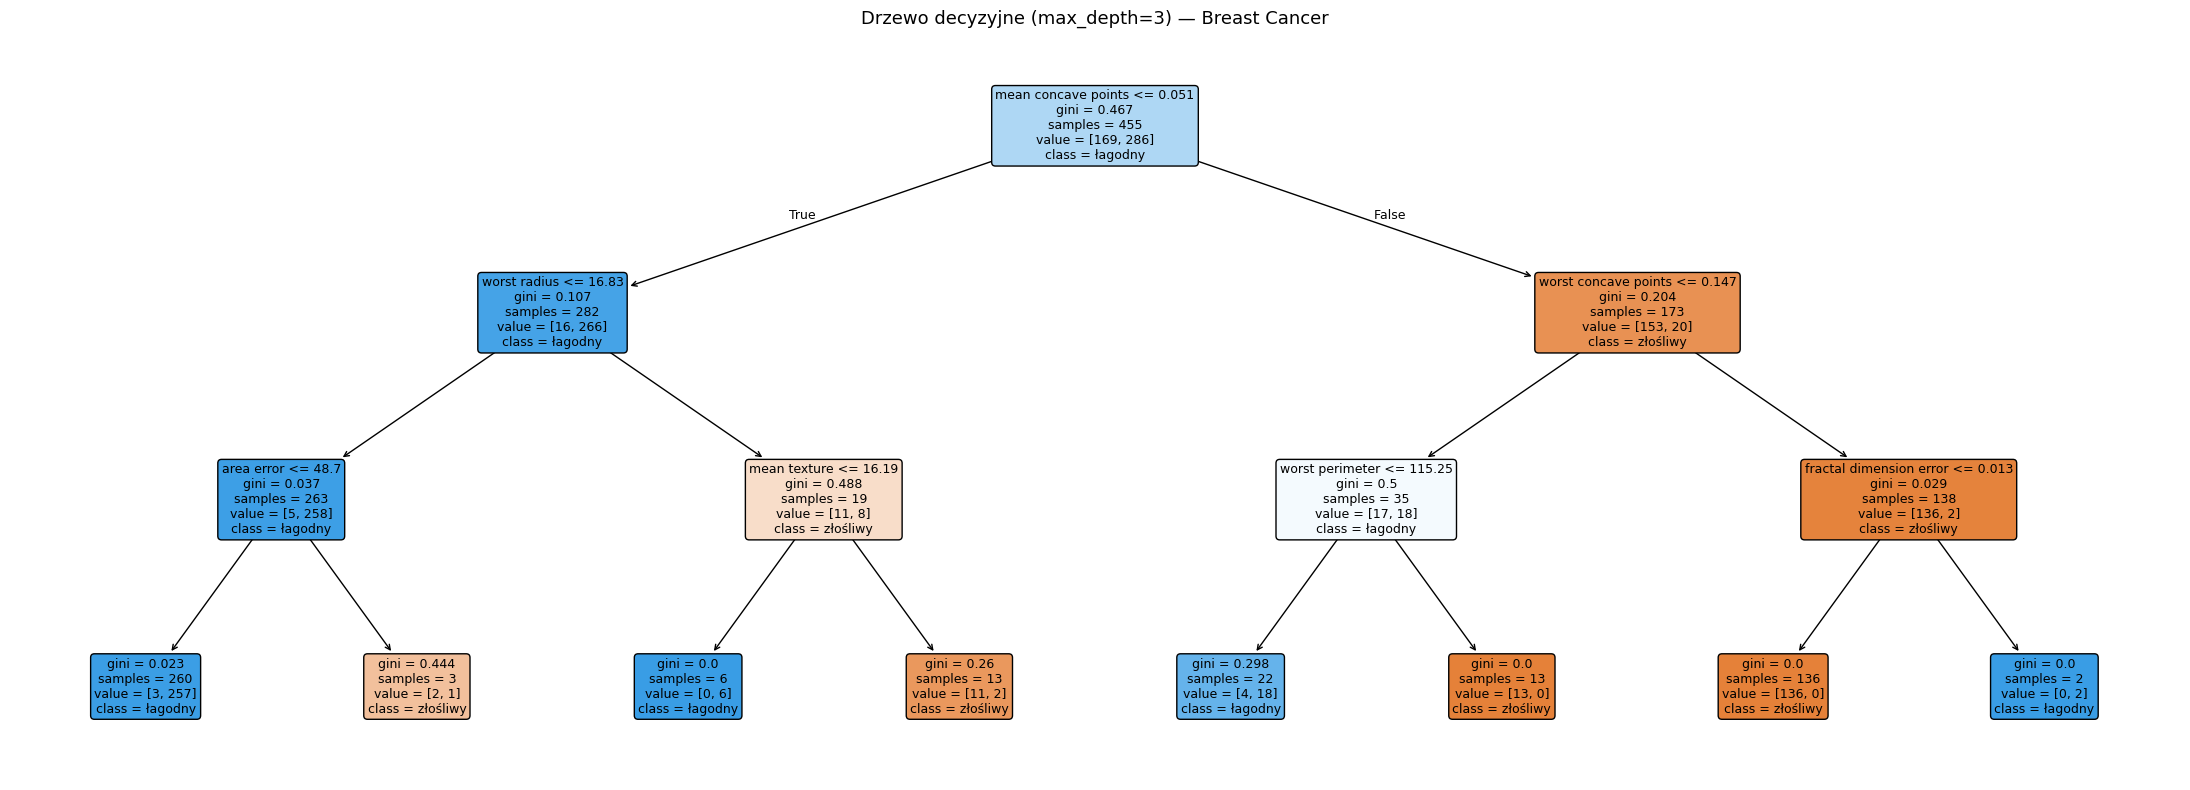

In [ ]:
#WIZUALIZACJA
plt.figure(figsize=(22, 8))
plot_tree(
    model_small,
    feature_names=cancer.feature_names,
    class_names=['złośliwy', 'łagodny'],
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title('Drzewo decyzyjne (max_depth=3) — Breast Cancer', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
#RĘCZNA PREDYKCJA
przyklad = X_test.iloc[[0]]
rzeczywista = y_test.iloc[0]
predykcja = model_small.predict(przyklad)[0]
prawdopodobienstwo = model_small.predict_proba(przyklad)[0]

print(f"Rzeczywista: {'łagodny' if rzeczywista == 1 else 'złośliwy'}")
print(f"Predykcja:   {'łagodny' if predykcja == 1 else 'złośliwy'}")
print(f"Pewność:     {max(prawdopodobienstwo):.2%}")

Rzeczywista: łagodny
Predykcja:   łagodny
Pewność:     98.85%


In [ ]:
#Overfitting i underfitting

##BARDZO WAZNE DWA POJECIA - TRZEBA POTRAFIC JE OPISAC ORAZ ROZROZNIC


depths = [2, 3, 4, 5, 7, 10, 15, 20, None]
results = []

for depth in depths:
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc  = accuracy_score(y_test,  model.predict(X_test))
    results.append({'depth': str(depth) if depth else 'brak', 'train': train_acc, 'test': test_acc})

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

depth    train     test
    2 0.929670 0.929825
    3 0.978022 0.947368
    4 0.995604 0.947368
    5 0.995604 0.947368
    7 1.000000 0.947368
   10 1.000000 0.947368
   15 1.000000 0.947368
   20 1.000000 0.947368
 brak 1.000000 0.947368


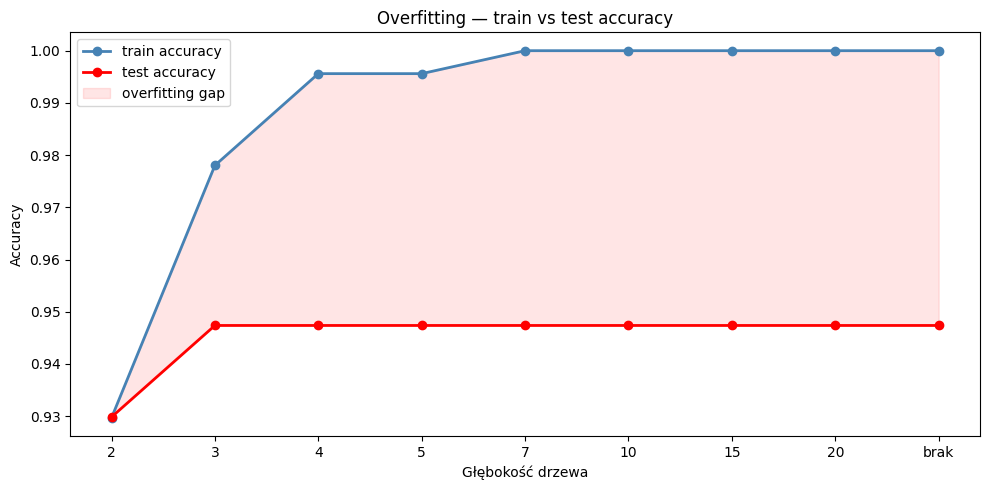

In [ ]:
#WIZUALIZACJA
plt.figure(figsize=(10, 5))
plt.plot(df_results['depth'], df_results['train'], marker='o', label='train accuracy', color='steelblue', linewidth=2)
plt.plot(df_results['depth'], df_results['test'],  marker='o', label='test accuracy',  color='red',       linewidth=2)
plt.fill_between(range(len(df_results)), df_results['train'], df_results['test'], alpha=0.1, color='red', label='overfitting gap')
plt.xticks(range(len(df_results)), df_results['depth'])
plt.xlabel('Głębokość drzewa')
plt.ylabel('Accuracy')
plt.title('Overfitting — train vs test accuracy')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
#Dobranie odpowiedniej glebokosci modelu
model_best = DecisionTreeClassifier(max_depth=5, random_state=42)
model_best.fit(X_train, y_train)
y_pred_best = model_best.predict(X_test)

print(f"Optymalny model (max_depth=5):")
print(f"  train accuracy: {accuracy_score(y_train, model_best.predict(X_train)):.4f}")
print(f"  test accuracy:  {accuracy_score(y_test, y_pred_best):.4f}")
print()
print(classification_report(y_test, y_pred_best, target_names=['złośliwy', 'łagodny']))

Optymalny model (max_depth=5):
  train accuracy: 0.9956
  test accuracy:  0.9474

              precision    recall  f1-score   support

    złośliwy       0.93      0.93      0.93        43
     łagodny       0.96      0.96      0.96        71

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



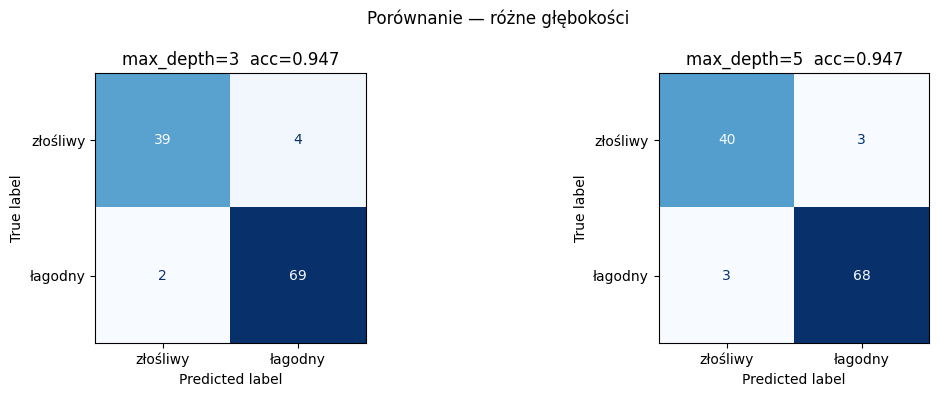

In [ ]:
#WIZUALIZACJA: macierz pomylek
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_small), display_labels=['złośliwy', 'łagodny']).plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title(f'max_depth=3  acc={accuracy_score(y_test, y_pred_small):.3f}')
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_best),  display_labels=['złośliwy', 'łagodny']).plot(ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title(f'max_depth=5  acc={accuracy_score(y_test, y_pred_best):.3f}')
plt.suptitle('Porównanie — różne głębokości', fontsize=12)
plt.tight_layout()
plt.show()

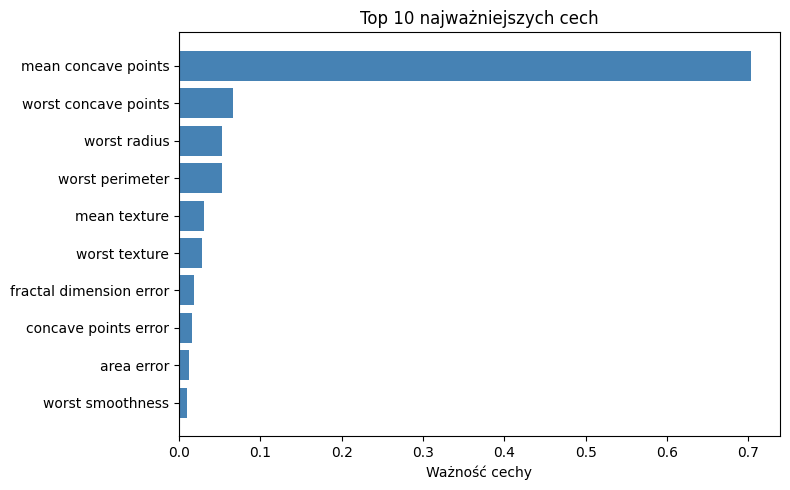

In [ ]:
# 🟢 WIZUALIZACJA: feature importance
importances = pd.DataFrame({'cecha': cancer.feature_names, 'ważność': model_best.feature_importances_}).sort_values('ważność', ascending=False)
plt.figure(figsize=(8, 5))
plt.barh(importances['cecha'][:10][::-1], importances['ważność'][:10][::-1], color='steelblue')
plt.xlabel('Ważność cechy')
plt.title('Top 10 najważniejszych cech')
plt.tight_layout()
plt.show()

REGRESJA

In [ ]:
#SETUP - ogarniecie danych
housing = fetch_california_housing()
df_h = pd.DataFrame(housing.data, columns=housing.feature_names)
df_h['Price'] = housing.target
X_h = df_h.drop(columns=['Price'])
y_h = df_h['Price']
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(X_h, y_h, test_size=0.2, random_state=42)
print("done!")

done!


In [ ]:
#MODEL!!!
depths = [2, 3, 4, 5, 7, 10, 15, 20, None]
results_r = []

for depth in depths:
    model = DecisionTreeRegressor(max_depth=depth, random_state=42)
    model.fit(X_train_h, y_train_h)
    train_r2 = r2_score(y_train_h, model.predict(X_train_h))
    test_r2  = r2_score(y_test_h,  model.predict(X_test_h))
    results_r.append({'depth': str(depth) if depth else 'brak', 'train': train_r2, 'test': test_r2})

df_r = pd.DataFrame(results_r)
print(df_r.to_string(index=False))

depth    train     test
    2 0.452045 0.424406
    3 0.537898 0.509763
    4 0.588659 0.554029
    5 0.637679 0.599732
    7 0.716698 0.651570
   10 0.834778 0.682948
   15 0.960656 0.646009
   20 0.995716 0.626758
 brak 1.000000 0.622076


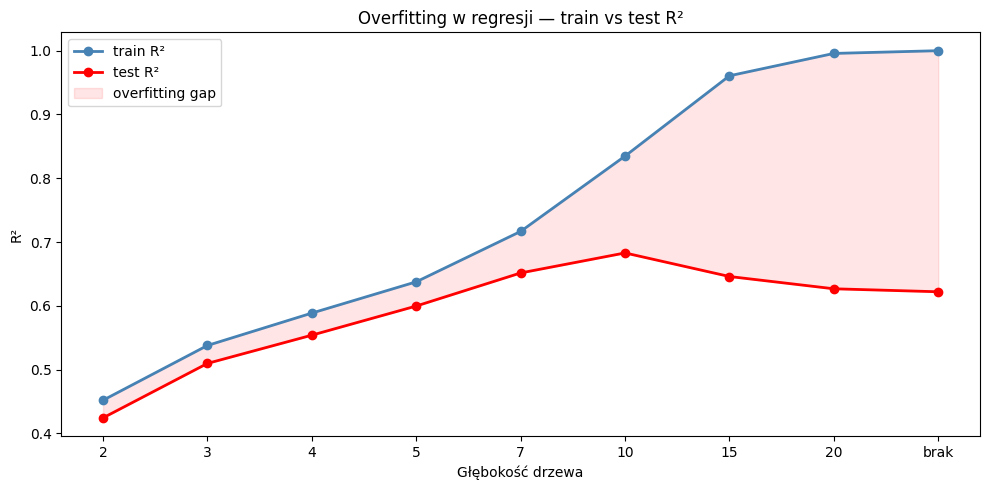

In [ ]:
# 🟢 WIZUALIZACJA
plt.figure(figsize=(10, 5))
plt.plot(df_r['depth'], df_r['train'], marker='o', label='train R²', color='steelblue', linewidth=2)
plt.plot(df_r['depth'], df_r['test'],  marker='o', label='test R²',  color='red',       linewidth=2)
plt.fill_between(range(len(df_r)), df_r['train'], df_r['test'], alpha=0.1, color='red', label='overfitting gap')
plt.xticks(range(len(df_r)), df_r['depth'])
plt.xlabel('Głębokość drzewa')
plt.ylabel('R²')
plt.title('Overfitting w regresji — train vs test R²')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
#Porównanie modeli -- setup
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

modele_clf = {
    'Regresja logistyczna':  (LogisticRegression(random_state=42).fit(X_train_s, y_train), X_train_s, X_test_s),
    'Drzewo (max_depth=3)':  (DecisionTreeClassifier(max_depth=3, random_state=42).fit(X_train, y_train), X_train, X_test),
    'Drzewo (max_depth=5)':  (DecisionTreeClassifier(max_depth=5, random_state=42).fit(X_train, y_train), X_train, X_test),
    'Drzewo (bez limitu)':   (DecisionTreeClassifier(random_state=42).fit(X_train, y_train), X_train, X_test),
}
modele_reg = {
    'Regresja liniowa':      LinearRegression().fit(X_train_h, y_train_h),
    'Drzewo (max_depth=3)':  DecisionTreeRegressor(max_depth=3, random_state=42).fit(X_train_h, y_train_h),
    'Drzewo (max_depth=5)':  DecisionTreeRegressor(max_depth=5, random_state=42).fit(X_train_h, y_train_h),
    'Drzewo (bez limitu)':   DecisionTreeRegressor(random_state=42).fit(X_train_h, y_train_h),
}
print("Modele gotowe!")

Modele gotowe!


In [ ]:
#Porównanie modeli -- main
print("KLASYFIKACJA — Breast Cancer")
print(f"{'Model':25s} {'Train':>8} {'Test':>8}")
print("-" * 45)
clf_results = []
for nazwa, (model, X_tr, X_te) in modele_clf.items():
    tr = accuracy_score(y_train, model.predict(X_tr))
    te = accuracy_score(y_test,  model.predict(X_te))
    clf_results.append({'model': nazwa, 'train': tr, 'test': te})
    print(f"{nazwa:25s} {tr:>8.4f} {te:>8.4f}")

print("\nREGRESJA — California Housing")
print(f"{'Model':25s} {'Train':>8} {'Test':>8}")
print("-" * 45)
reg_results = []
for nazwa, model in modele_reg.items():
    tr = r2_score(y_train_h, model.predict(X_train_h))
    te = r2_score(y_test_h,  model.predict(X_test_h))
    reg_results.append({'model': nazwa, 'train': tr, 'test': te})
    print(f"{nazwa:25s} {tr:>8.4f} {te:>8.4f}")

KLASYFIKACJA — Breast Cancer
Model                        Train     Test
---------------------------------------------
Regresja logistyczna        0.9868   0.9737
Drzewo (max_depth=3)        0.9780   0.9474
Drzewo (max_depth=5)        0.9956   0.9474
Drzewo (bez limitu)         1.0000   0.9474

REGRESJA — California Housing
Model                        Train     Test
---------------------------------------------
Regresja liniowa            0.6126   0.5758
Drzewo (max_depth=3)        0.5379   0.5098
Drzewo (max_depth=5)        0.6377   0.5997
Drzewo (bez limitu)         1.0000   0.6221


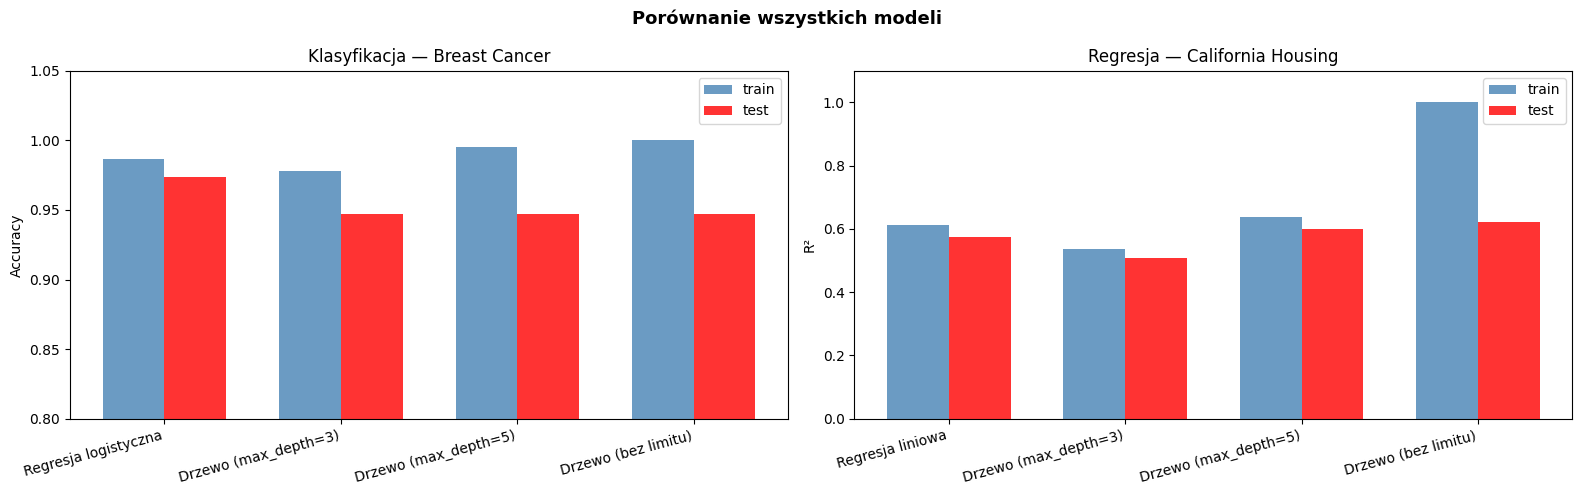

In [ ]:
#WIZUALIZACJA
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
w = 0.35

df_clf = pd.DataFrame(clf_results)
x = range(len(df_clf))
axes[0].bar([i - w/2 for i in x], df_clf['train'], w, label='train', color='steelblue', alpha=0.8)
axes[0].bar([i + w/2 for i in x], df_clf['test'],  w, label='test',  color='red',       alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(df_clf['model'], rotation=15, ha='right')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Klasyfikacja — Breast Cancer')
axes[0].set_ylim(0.8, 1.05)
axes[0].legend()

df_reg = pd.DataFrame(reg_results)
x = range(len(df_reg))
axes[1].bar([i - w/2 for i in x], df_reg['train'], w, label='train', color='steelblue', alpha=0.8)
axes[1].bar([i + w/2 for i in x], df_reg['test'],  w, label='test',  color='red',       alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(df_reg['model'], rotation=15, ha='right')
axes[1].set_ylabel('R²')
axes[1].set_title('Regresja — California Housing')
axes[1].set_ylim(0, 1.1)
axes[1].legend()

plt.suptitle('Porównanie wszystkich modeli', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()